# **Validação Humana dos Rótulos**

----------
# Comparacao dos moledos BERTimbau Base e Stevillis
-------------


In [ ]:
# ==========================================
# Bibliotecas
# ==========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# ==========================================
# Mostra o texto completo em cada célula
# ==========================================
pd.set_option("display.max_colwidth", None)  

In [ ]:
# ==========================================
# Carregar os dados rotulados por validação humana
# ==========================================
df = pd.read_csv('Humana-amostras_50_por_sentimento_cidade.csv')
df.head(300)

,Validacao-humana,Base-sentimento,Stev-sentimento,cidade,texto_limpo
0,POSITIVO,POSITIVO,POSITIVO,Lisboa,"Adoramos a casa de Rui e Elsa, eles foram claros e rápidos nas nossas comunicações, achei o apartamento ainda mais bonito do que eu esperava pelas fotos, todo renovado, comportou muito bem meu grupo de pessoas, com espaço e conforto. Nos permitiram deixar as malas no apartamento antes do check in e achei ótimo que as coisas básicas como sabão para lavar roupas, detergente, papel higiênico, temperos estavam inclusos, o que evita o nosso gasto com coisas que não serão utilizadas no resto da viagem. Gostei da localização; pelo que vi em Lisboa, se você está perto do metro, você está perto de tudo. Obs. Importante notar que para pessoas com dificuldades motoras pode não ser a melhor opção, uma vez que tem escada para chegar ao apartamento e uns - minutos de caminhada em ruas de pedras."
1,POSITIVO,POSITIVO,POSITIVO,Lisboa,"A estadia no apartamento de Filipa foi maravilhosa. Tudo estava como descrito no anúncio, limpeza e organização impecáveis. Sempre atenciosa, respondia rapidamente nossas dúvidas. Vamos voltar, com certeza! E recomendo muito!"
2,POSITIVO,NEGATIVO,POSITIVO,Lisboa,"O apartamento bastante espaçoso, moderno, com todas as necessidades para uma boa estadia. Local tranquilo e proximo a estação do metro de Picoas. Pedro foi bastante simpático e atencioso."
3,POSITIVO,POSITIVO,POSITIVO,Lisboa,Gostamos da Zona e o apartamento é muito limpo e aconchegante. A Fátima é uma anfitriã muito colaborativo e discreta.
4,POSITIVO,POSITIVO,POSITIVO,Lisboa,Apartamento com quartos ideal para famílias. O local ideal para uma estadia em Lisboa. Havemos de repetir!


-------
## Percentagem dos rótulos da Análise de sentimento da validação humana
----------

In [ ]:
# ==========================================
# Criar tabela a partir da coluna 'sentimento'
# ==========================================
contagens = df['Validacao-humana'].value_counts()
percentagens = df['Validacao-humana'].value_counts(normalize=True).mul(100).round(1)

sentimentos = pd.DataFrame({
    'sentimento': contagens.index,
    'contagem': contagens.values,
    'percentagem': percentagens.values
})

# ==========================================
# Criar coluna formatada para apresentação
# ==========================================
sentimentos['percentagem_label'] = sentimentos['percentagem'].astype(str) + '%'

# ==========================================
# Mostrar tabela em formato DataFrame
# ==========================================
print("Analise de Sentimento amostral (300 reviews = 50% Lisboa e 50% Rio de Janeiro) por validacao humana")
display(sentimentos[['sentimento', 'contagem', 'percentagem_label']])

Analise de Sentimento amostral (300 reviews = 50% Lisboa e 50% Rio de Janeiro) por validacao humana


,sentimento,contagem,percentagem_label
0,positivo,132,44.0%
1,neutro,109,36.3%
2,negativo,59,19.7%


--------
## Métricas para comparação dos modelos com a validação humana
----------

In [ ]:
# ==========================================
# Garantir que os rótulos estão em maiúsculas e sem espaços extra
# ==========================================
for col in ['Validacao-humana', 'Stev-sentimento', 'Base-sentimento']:
    df[col] = df[col].astype(str).str.strip().str.upper()

# ==========================================
# Função para avaliar um modelo
# ==========================================
def avaliar_modelo(df, col_real, col_pred):
    y_true = df[col_real]
    y_pred = df[col_pred]

    acuracia = accuracy_score(y_true, y_pred)
    relatorio = classification_report(y_true, y_pred, labels=['POSITIVO', 'NEGATIVO', 'NEUTRO'], output_dict=True, zero_division=0)
    matriz = confusion_matrix(y_true, y_pred, labels=['POSITIVO', 'NEGATIVO', 'NEUTRO'])

    resultado = {
        'modelo': col_pred,
        'acuracia': acuracia,
        'precision_positivo': relatorio['POSITIVO']['precision'],
        'recall_positivo': relatorio['POSITIVO']['recall'],
        'f1_positivo': relatorio['POSITIVO']['f1-score'],
        'precision_negativo': relatorio['NEGATIVO']['precision'],
        'recall_negativo': relatorio['NEGATIVO']['recall'],
        'f1_negativo': relatorio['NEGATIVO']['f1-score'],
        'precision_neutro': relatorio['NEUTRO']['precision'],
        'recall_neutro': relatorio['NEUTRO']['recall'],
        'f1_neutro': relatorio['NEUTRO']['f1-score']
    }

    return resultado, matriz, relatorio

# ==========================================
# Avaliar os dois modelos
# ==========================================
resultado_stev, matriz_stev, relatorio_stev = avaliar_modelo(df, 'Validacao-humana', 'Stev-sentimento')
resultado_base, matriz_base, relatorio_base = avaliar_modelo(df, 'Validacao-humana', 'Base-sentimento')

# ==========================================
# Resumo comparativo
# ==========================================
df_resultados = pd.DataFrame([resultado_stev, resultado_base])
display(df_resultados)

,modelo,acuracia,precision_positivo,recall_positivo,f1_positivo,precision_negativo,recall_negativo,f1_negativo,precision_neutro,recall_neutro,f1_neutro
0,Stev-sentimento,0.703333,0.970000,0.734848,0.836207,0.530000,0.898305,0.666667,0.610000,0.559633,0.583732
1,Base-sentimento,0.310000,0.397516,0.484848,0.436860,0.171875,0.372881,0.235294,0.636364,0.064220,0.116667


-----------
## Matriz de confusão para comparação do desempenho dos modelos
----------

In [ ]:
# ==========================================
# Normalizar os rótulos
# ==========================================
for col in ['Validacao-humana', 'Stev-sentimento', 'Base-sentimento']:
    df[col] = df[col].astype(str).str.strip().str.upper()

labels = ['POSITIVO', 'NEGATIVO', 'NEUTRO']

# ==========================================
# Matrizes de confusão
# ==========================================
cm_stev = confusion_matrix(df['Validacao-humana'], df['Stev-sentimento'], labels=labels)
cm_base = confusion_matrix(df['Validacao-humana'], df['Base-sentimento'], labels=labels)

# ==========================================
# Escala de cores comum
# ==========================================
vmin = 0
vmax = max(cm_stev.max(), cm_base.max())

# ==========================================
# Criar figura com 2 gráficos
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.heatmap(
    cm_stev,
    annot=True,
    fmt='d',
    cmap='Blues',
    vmin=vmin,
    vmax=vmax,
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0],
    cbar=True
)
axes[0].set_title('Matriz de Confusão - Modelo BERTimbau-Stevillis')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Blues',
    vmin=vmin,
    vmax=vmax,
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1],
    cbar=True
)
axes[1].set_title('Matriz de Confusão - Modelo BERTimbau-Base')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

# ==========================================
# Ajustar layout e salvar figura
# ==========================================
plt.tight_layout()
plt.savefig('matriz_confusao_modelos_BERTimbal_Base_Stevillis.png', dpi=300, bbox_inches='tight')
plt.show()

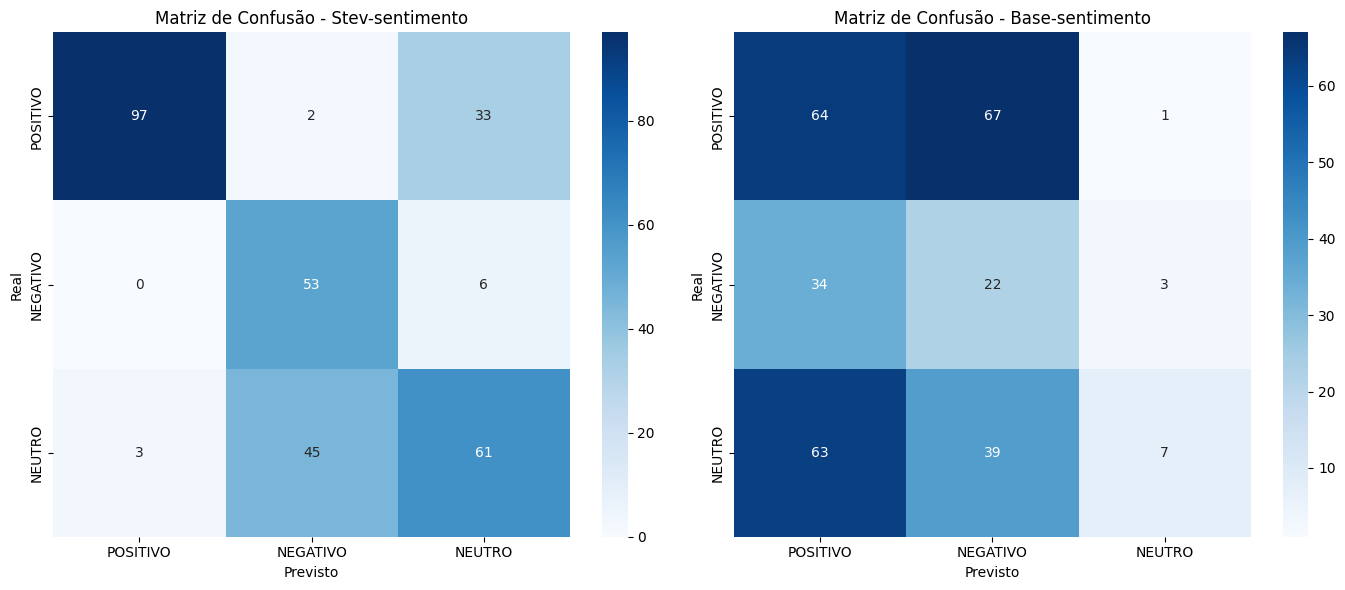

In [ ]:
# ==========================================
# Normalizar os rótulos
# ==========================================
for col in ['Validacao-humana', 'Stev-sentimento', 'Base-sentimento']:
    df[col] = df[col].astype(str).str.strip().str.upper()

labels = ['POSITIVO', 'NEGATIVO', 'NEUTRO']

# ==========================================
# Matriz de confusão do Stev-sentimento
# ==========================================
cm_stev = confusion_matrix(df['Validacao-humana'], df['Stev-sentimento'], labels=labels)

# ==========================================
# Matriz de confusão do Base-sentimento
# ==========================================
cm_base = confusion_matrix(df['Validacao-humana'], df['Base-sentimento'], labels=labels)

# ==========================================
# Criar figura com 2 gráficos
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    cm_stev,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusão - Modelo BERTimbau-Stevillis')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)
axes[1].set_title('Matriz de Confusão - Modelo BERTimbau-Base')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

# ==========================================
# Ajustar layout e salvar figura
# ==========================================
plt.tight_layout()
plt.savefig('matriz_confusao_modelos_BERTimbal_Base_Stevillis.png', dpi=300, bbox_inches='tight')
plt.show()

